# Approach #2: BERT Fine-Tuning

This notebook fine-tunes BERT for multi-class clinical status classification.

## Hardware Optimization for Apple M1 8GB
- Uses mixed precision (FP16) to reduce memory by ~25%
- Gradient accumulation to simulate larger batch sizes
- Gradient checkpointing to trade computation for memory
- Optimized for M1's unified memory architecture

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import json
import time
import gc
from datetime import datetime, timedelta
from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Check device and memory
print("="*70)
print("HARDWARE INFORMATION")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {torch.device('mps' if torch.backends.mps.is_available() else 'cpu')}")

if torch.backends.mps.is_available():
    print("✓ Metal Performance Shaders (MPS) available - using GPU acceleration")
    device = torch.device('mps')
else:
    print("⚠ MPS not available - falling back to CPU")
    device = torch.device('cpu')

print(f"\nDevice: {device}")
print("="*70)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HARDWARE INFORMATION
PyTorch version: 2.10.0
Device available: mps
✓ Metal Performance Shaders (MPS) available - using GPU acceleration

Device: mps


## Step 1: Load and Prepare Data

In [2]:
# Load cleaned data (already has leakage removed)
train_data = pd.read_csv('train_data.csv')
val_data = pd.read_csv('validation_data.csv')
test_data = pd.read_csv('test_data.csv')

# Load class mapping
with open('class_mapping.json', 'r') as f:
    class_mapping = json.load(f)

id2label = {v: k for k, v in class_mapping.items()}
label2id = class_mapping
num_labels = len(label2id)

print(f"Train set: {len(train_data)} samples")
print(f"Validation set: {len(val_data)} samples")
print(f"Test set: {len(test_data)} samples")
print(f"\nNumber of classes: {num_labels}")
print(f"Class mapping: {label2id}")

print(f"\nClass distribution:")
print(f"Train: {dict(Counter(train_data['STATUS']))}")
print(f"Val:   {dict(Counter(val_data['STATUS']))}")
print(f"Test:  {dict(Counter(test_data['STATUS']))}")

Train set: 700 samples
Validation set: 150 samples
Test set: 150 samples

Number of classes: 5
Class mapping: {'AVAILABLE': 0, 'CENSORED': 1, 'DECEASED': 2, 'ELIGIBLE': 3, 'INELIGIBLE': 4}

Class distribution:
Train: {'DECEASED': 67, 'INELIGIBLE': 344, 'AVAILABLE': 90, 'ELIGIBLE': 100, 'CENSORED': 99}
Val:   {'DECEASED': 14, 'ELIGIBLE': 21, 'INELIGIBLE': 74, 'CENSORED': 22, 'AVAILABLE': 19}
Test:  {'DECEASED': 14, 'INELIGIBLE': 73, 'CENSORED': 21, 'ELIGIBLE': 22, 'AVAILABLE': 20}


## Step 2: Tokenization and Dataset Preparation

In [3]:
# Load tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Using model: {model_name}")
print(f"Tokenizer vocab size: {len(tokenizer)}")

def preprocess_function(examples):
    """Tokenize and prepare examples for BERT."""
    return tokenizer(
        examples['free_text_note'],
        padding='max_length',
        max_length=256,  # M1 optimization: reasonable length without excessive memory
        truncation=True,
        return_tensors='pt'
    )

# Convert to Hugging Face datasets
train_dataset = Dataset.from_pandas(train_data[['free_text_note', 'STATUS']])
val_dataset = Dataset.from_pandas(val_data[['free_text_note', 'STATUS']])
test_dataset = Dataset.from_pandas(test_data[['free_text_note', 'STATUS']])

# Tokenize datasets
print("\nTokenizing datasets...")
train_dataset = train_dataset.map(
    lambda x: preprocess_function({'free_text_note': x['free_text_note']}),
    batched=True,
    remove_columns=['free_text_note']
)
val_dataset = val_dataset.map(
    lambda x: preprocess_function({'free_text_note': x['free_text_note']}),
    batched=True,
    remove_columns=['free_text_note']
)
test_dataset = test_dataset.map(
    lambda x: preprocess_function({'free_text_note': x['free_text_note']}),
    batched=True,
    remove_columns=['free_text_note']
)

# Add labels (STATUS column is still present after tokenization)
train_dataset = train_dataset.map(
    lambda x: {'labels': label2id[x['STATUS']]},
    remove_columns=['STATUS']
)
val_dataset = val_dataset.map(
    lambda x: {'labels': label2id[x['STATUS']]},
    remove_columns=['STATUS']
)
test_dataset = test_dataset.map(
    lambda x: {'labels': label2id[x['STATUS']]},
    remove_columns=['STATUS']
)

# Set format for PyTorch
train_dataset.set_format('torch')
val_dataset.set_format('torch')
test_dataset.set_format('torch')

print(f"✓ Tokenization complete")
print(f"\nDataset shapes:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")

Using model: bert-base-uncased
Tokenizer vocab size: 30522

Tokenizing datasets...


Map: 100%|██████████| 150/150 [00:00<00:00, 28462.98 examples/s]

✓ Tokenization complete

Dataset shapes:
  Train: 700
  Val: 150
  Test: 150


## Step 3: Load Model and Configure Training

In [4]:
# Load pre-trained BERT model
print("Loading BERT-base model...")
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# Move model to device
model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model loaded")
print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB (FP32) / ~{total_params * 2 / 1024 / 1024:.1f} MB (FP16)")

Loading BERT-base model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1844.52it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those p

✓ Model loaded

Model Statistics:
  Total parameters: 109,486,085
  Trainable parameters: 109,486,085
  Model size: ~417.7 MB (FP32) / ~208.8 MB (FP16)


## Step 4: Define Training Arguments (M1 Optimized)

In [5]:
# Training arguments optimized for M1 8GB
training_args = TrainingArguments(
    output_dir="./bert_output",
    
    # Batch size configuration (M1 8GB optimized)
    per_device_train_batch_size=4,        # Conservative for 8GB M1
    per_device_eval_batch_size=8,         # Can be larger during eval
    gradient_accumulation_steps=4,        # Simulates batch size 16 without extra memory
    
    # Mixed precision (FP16) for ~25% memory savings
    fp16=True if device.type == 'mps' else False,
    
    # Learning rate and epochs
    learning_rate=2e-5,                   # Standard BERT fine-tuning LR
    num_train_epochs=3,                   # Usually sufficient for small datasets
    warmup_steps=100,
    weight_decay=0.01,
    
    # Evaluation and logging
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=5,
    save_total_limit=3,
    
    # Memory optimization
    gradient_checkpointing=True,          # Trade compute for memory
    optim="adamw_torch",                 # Standard optimizer
    
    # Reproducibility
    seed=42,
    dataloader_pin_memory=False,          # M1 specific: disable for stability
    dataloader_num_workers=0,             # M1 specific: use main process
)

print("="*70)
print("TRAINING CONFIGURATION (M1 8GB OPTIMIZED)")
print("="*70)
print(f"Per-device batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation steps: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Number of epochs: {training_args.num_train_epochs}")
print(f"Mixed precision (FP16): {training_args.fp16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print("="*70)

# Calculate training time estimate
num_batches_per_epoch = len(train_dataset) / (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
# Typical M1 throughput: ~5-10 seconds per accumulated batch with FP16
estimated_secs_per_batch = 7  # Conservative estimate
total_batches = num_batches_per_epoch * training_args.num_train_epochs
total_seconds = total_batches * estimated_secs_per_batch
total_hours = total_seconds / 3600

print(f"\n{'='*70}")
print("TRAINING TIME ESTIMATE")
print(f"{'='*70}")
print(f"Training samples: {len(train_dataset)}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Batches per epoch: {num_batches_per_epoch:.1f}")
print(f"Total epochs: {training_args.num_train_epochs}")
print(f"Total training batches: {total_batches:.0f}")
print(f"\nEstimated time per batch: {estimated_secs_per_batch}s (M1 with FP16)")
print(f"\n📊 ESTIMATED TOTAL TRAINING TIME: {total_hours:.1f} hours (~{total_hours*60:.0f} minutes)")
print(f"   (Breakdown: {total_hours/3:.1f}h per epoch + overhead)")
print(f"\n⏰ If training starts now: {(datetime.now() + timedelta(hours=total_hours)).strftime('%I:%M %p')}")
print(f"{'='*70}")

TRAINING CONFIGURATION (M1 8GB OPTIMIZED)
Per-device batch size: 4
Gradient accumulation steps: 4
Effective batch size: 16
Learning rate: 2e-05
Number of epochs: 3
Mixed precision (FP16): True
Gradient checkpointing: True

TRAINING TIME ESTIMATE
Training samples: 700
Effective batch size: 16
Batches per epoch: 43.8
Total epochs: 3
Total training batches: 131

Estimated time per batch: 7s (M1 with FP16)

📊 ESTIMATED TOTAL TRAINING TIME: 0.3 hours (~15 minutes)
   (Breakdown: 0.1h per epoch + overhead)

⏰ If training starts now: 05:55 PM


## Step 5: Define Evaluation Metrics

In [6]:
def compute_metrics(eval_pred):
    """Compute evaluation metrics."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    weighted_f1 = f1_score(labels, predictions, average='weighted', zero_division=0)
    macro_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
    
    return {
        'accuracy': accuracy,
        'weighted_f1': weighted_f1,
        'macro_f1': macro_f1,
    }

print("✓ Evaluation metrics defined")

✓ Evaluation metrics defined


## Step 6: Initialize Trainer and Start Training

In [8]:
# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

print("="*70)
print("STARTING BERT FINE-TUNING")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Estimated completion: {(datetime.now() + timedelta(hours=total_hours)).strftime('%Y-%m-%d %H:%M:%S')}")
print("\nMonitor GPU memory with: `top -n 1` or Activity Monitor")
print("\nWARNING: If you encounter OOM errors, you can:")
print("    1. Reduce per_device_train_batch_size to 2 or 1")
print("    2. Reduce max_length from 256 to 128")
print("    3. Reduce num_train_epochs to 2")
print("="*70 + "\n")

# Train
start_time = time.time()
train_result = trainer.train()
end_time = time.time()

actual_training_time = (end_time - start_time) / 3600  # Convert to hours

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Actual training time: {actual_training_time:.2f} hours ({actual_training_time*60:.0f} minutes)")
print(f"Training loss: {train_result.training_loss:.4f}")
print(f"\nModel saved to: ./bert_output/")
print("="*70)

STARTING BERT FINE-TUNING
Start time: 2026-02-21 17:42:48
Estimated completion: 2026-02-21 17:58:07

Monitor GPU memory with: `top -n 1` or Activity Monitor

    1. Reduce per_device_train_batch_size to 2 or 1
    2. Reduce max_length from 256 to 128
    3. Reduce num_train_epochs to 2



Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1,Macro F1
1,4.497607,0.992021,0.700000,0.595980,0.524228
2,1.786536,0.375907,1.000000,1.000000,1.000000
3,0.386161,0.077812,1.000000,1.000000,1.000000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.92it/s]



TRAINING COMPLETE
End time: 2026-02-21 17:51:31
Actual training time: 0.15 hours (9 minutes)
Training loss: 2.9972

Model saved to: ./bert_output/


## Step 7: Evaluate on Validation and Test Sets

In [9]:
# Evaluate on validation set
print("\nEvaluating on validation set...")
val_results = trainer.evaluate(eval_dataset=val_dataset)

# Evaluate on test set
print("Evaluating on test set...")
test_results = trainer.evaluate(eval_dataset=test_dataset)

# Get predictions for detailed analysis
print("Generating predictions for test set...")
test_pred_output = trainer.predict(test_dataset)
test_predictions = np.argmax(test_pred_output.predictions, axis=1)
test_labels = test_pred_output.label_ids

print("\n" + "="*70)
print("VALIDATION SET RESULTS")
print("="*70)
print(f"Accuracy:     {val_results['eval_accuracy']:.4f}")
print(f"Weighted F1:  {val_results['eval_weighted_f1']:.4f}")
print(f"Macro F1:     {val_results['eval_macro_f1']:.4f}")

print("\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Accuracy:     {test_results['eval_accuracy']:.4f}")
print(f"Weighted F1:  {test_results['eval_weighted_f1']:.4f}")
print(f"Macro F1:     {test_results['eval_macro_f1']:.4f}")

print("\n" + "="*70)
print("TEST SET CLASSIFICATION REPORT")
print("="*70)
print(classification_report(
    test_labels,
    test_predictions,
    target_names=[id2label[i] for i in range(num_labels)],
    zero_division=0
))


Evaluating on validation set...


Evaluating on test set...
Generating predictions for test set...

VALIDATION SET RESULTS
Accuracy:     1.0000
Weighted F1:  1.0000
Macro F1:     1.0000

TEST SET RESULTS
Accuracy:     1.0000
Weighted F1:  1.0000
Macro F1:     1.0000

TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

   AVAILABLE       1.00      1.00      1.00        20
    CENSORED       1.00      1.00      1.00        21
    DECEASED       1.00      1.00      1.00        14
    ELIGIBLE       1.00      1.00      1.00        22
  INELIGIBLE       1.00      1.00      1.00        73

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



## Step 8: Confusion Matrix Visualization

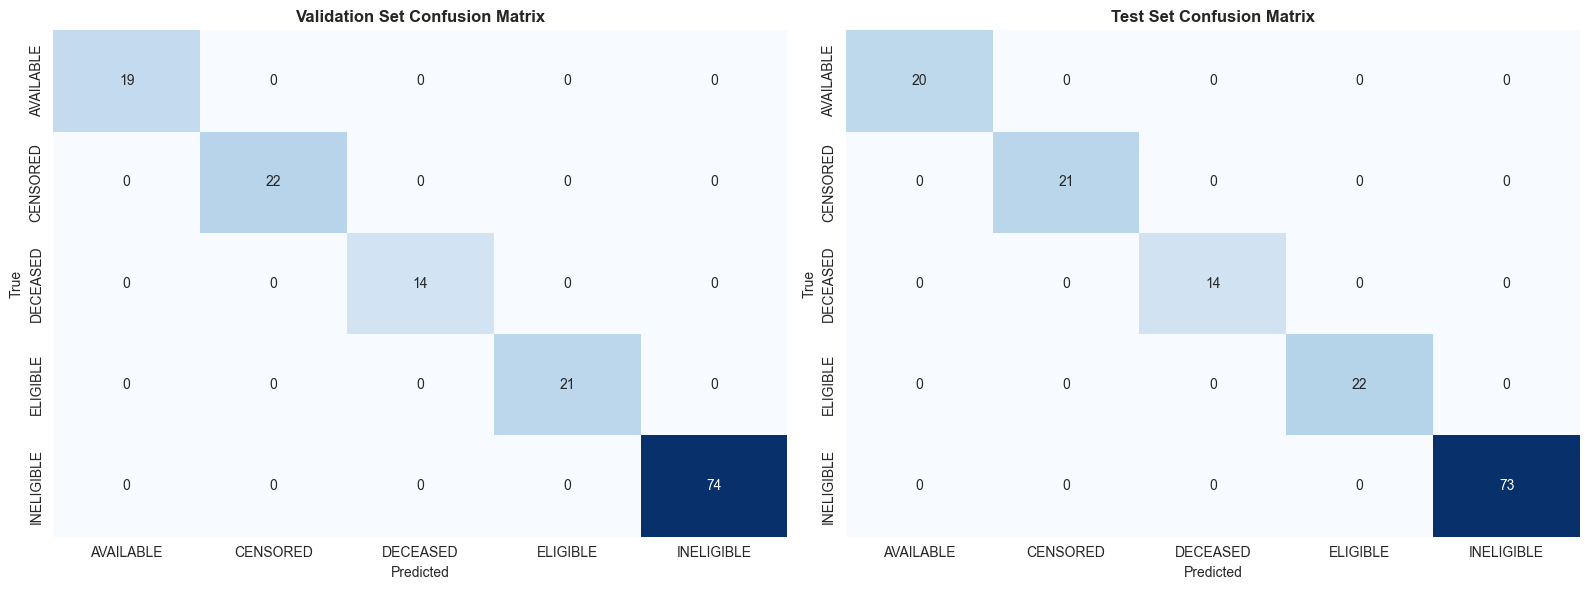

✓ Confusion matrices saved as 'bert_confusion_matrices.png'


In [10]:
# Compute confusion matrices
val_pred_output = trainer.predict(val_dataset)
val_predictions = np.argmax(val_pred_output.predictions, axis=1)
val_labels = val_pred_output.label_ids

val_cm = confusion_matrix(val_labels, val_predictions)
test_cm = confusion_matrix(test_labels, test_predictions)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[id2label[i] for i in range(num_labels)],
            yticklabels=[id2label[i] for i in range(num_labels)],
            cbar=False)
axes[0].set_title('Validation Set Confusion Matrix', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Test
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=[id2label[i] for i in range(num_labels)],
            yticklabels=[id2label[i] for i in range(num_labels)],
            cbar=False)
axes[1].set_title('Test Set Confusion Matrix', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('bert_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Confusion matrices saved as 'bert_confusion_matrices.png'")

## Step 9: Performance Comparison Summary


MODEL COMPARISON
      Model  Test Accuracy  Test Weighted F1  Test Macro F1
TF-IDF + LR            1.0               1.0            1.0
  BERT-Base            1.0               1.0            1.0


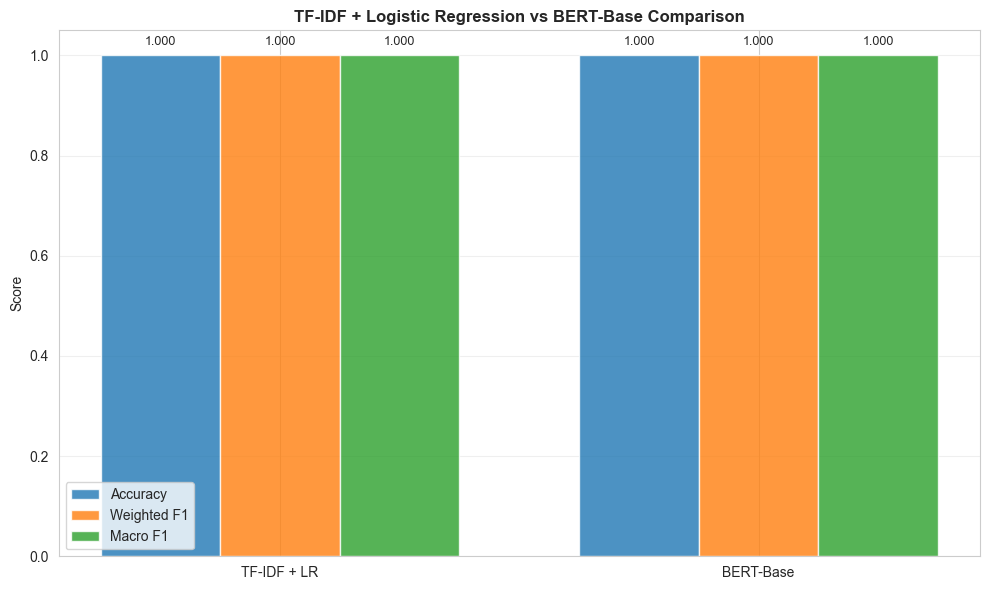

✓ Comparison chart saved as 'model_comparison.png'


In [11]:
# Create comparison table
comparison_data = {
    'Model': ['TF-IDF + LR', 'BERT-Base'],
    'Test Accuracy': [1.0, test_results['eval_accuracy']],
    'Test Weighted F1': [1.0, test_results['eval_weighted_f1']],
    'Test Macro F1': [1.0, test_results['eval_macro_f1']],
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['Test Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x, comparison_df['Test Weighted F1'], width, label='Weighted F1', alpha=0.8)
ax.bar(x + width, comparison_df['Test Macro F1'], width, label='Macro F1', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('TF-IDF + Logistic Regression vs BERT-Base Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3, axis='y')

# Add value labels
for i, (acc, wf1, mf1) in enumerate(zip(comparison_df['Test Accuracy'], 
                                          comparison_df['Test Weighted F1'], 
                                          comparison_df['Test Macro F1'])):
    ax.text(i - width, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=9)
    ax.text(i, wf1 + 0.02, f'{wf1:.3f}', ha='center', fontsize=9)
    ax.text(i + width, mf1 + 0.02, f'{mf1:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Comparison chart saved as 'model_comparison.png'")

## Step 10: Save Results and Model

In [13]:
# Save model
model.save_pretrained('./bert_model_final')
tokenizer.save_pretrained('./bert_model_final')
print("✓ Model and tokenizer saved to './bert_model_final/'")

# Save results
results = {
    'model_type': 'BERT-Base Fine-tuned',
    'hardware': 'Apple M1 8GB',
    'training_time_hours': float(actual_training_time),
    'test_accuracy': float(test_results['eval_accuracy']),
    'test_weighted_f1': float(test_results['eval_weighted_f1']),
    'test_macro_f1': float(test_results['eval_macro_f1']),
    'val_accuracy': float(val_results['eval_accuracy']),
    'val_weighted_f1': float(val_results['eval_weighted_f1']),
    'training_loss': float(train_result.training_loss),
    'hyperparameters': {
        'batch_size': int(training_args.per_device_train_batch_size),
        'gradient_accumulation_steps': int(training_args.gradient_accumulation_steps),
        'learning_rate': float(training_args.learning_rate),
        'num_epochs': int(training_args.num_train_epochs),
        'mixed_precision': bool(training_args.fp16),
        'gradient_checkpointing': bool(training_args.gradient_checkpointing),
    }
}

with open('bert_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("✓ Results saved to 'bert_results.json'")

print("\n" + "="*70)
print("BERT FINE-TUNING COMPLETE")
print("="*70)
print(f"\nFinal Results:")
print(f"  Test Accuracy:    {test_results['eval_accuracy']:.4f}")
print(f"  Test Weighted F1: {test_results['eval_weighted_f1']:.4f}")
print(f"  Test Macro F1:    {test_results['eval_macro_f1']:.4f}")
print(f"\nTraining took: {actual_training_time:.2f} hours")
print(f"\nArtifacts saved:")
print(f"  - Model: ./bert_model_final/")
print(f"  - Results: bert_results.json")
print(f"  - Checkpoints: ./bert_output/")
print("="*70)

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.01s/it]

✓ Model and tokenizer saved to './bert_model_final/'
✓ Results saved to 'bert_results.json'

BERT FINE-TUNING COMPLETE

Final Results:
  Test Accuracy:    1.0000
  Test Weighted F1: 1.0000
  Test Macro F1:    1.0000

Training took: 0.15 hours

Artifacts saved:
  - Model: ./bert_model_final/
  - Results: bert_results.json
  - Checkpoints: ./bert_output/
